# Check the datasets

Check datasets used for training are in same coordinate system, have apropreate files sizes, etc.

In [10]:
import h5py
import numpy as np
import glob
import os
import yaml
from matplotlib import pyplot as plt

from matplotlib.colors import LogNorm

from src.evaluation import plotting

In [18]:
as_configs = yaml.safe_load(open("../config/padded_allshowers.yaml", 'r'))["data"]
ph_configs = yaml.safe_load(open("../config/padded_photons.yaml", 'r'))["data"]
cc3_configs = yaml.safe_load(open("../config/calocloud3.yaml", 'r'))["data"]

In [19]:
 
# ---------------------------------------------------------------------------
# knobs
# ---------------------------------------------------------------------------
N_BINS = 50
EVENT_CHUNK = 256          # events pulled off disk at a time in the loops
EVENT_INDICES = (0, 1)     # which events to draw as scatter plots
MAX_FILES = None           # set to e.g. 2 for a quick smoke test, None = all
NORMALISE = True           # plot fractions, so the two datasets are comparable
LOG_ENERGY_BINS = True     # deposit energies span many orders of magnitude
SAVE_DIR = None            # e.g. "plots", or None to only show
 
POINT_LABELS = ["x", "y", "z", "E"]
ENERGY_COL = 3             # points are stored as (x, y, z, e)
DIRECTION_LABELS = ["$p_x$", "$p_y$", "$p_z$"]
 
datasets = {"all showers": as_configs, "photons": ph_configs, "caloclouds 3": cc3_configs}
 


In [20]:

# ---------------------------------------------------------------------------
# reading
# ---------------------------------------------------------------------------
def dataset_files(config, max_files=MAX_FILES):
    """All files matching the (possibly templated) dataset_path."""
    path = config["dataset_path"]
    pattern = path.format(*(["*"] * path.count("{")))
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files found with pattern {pattern}")
    return files[:max_files]
 
 
def read_event_level(open_file, key):
    """
    Event level data can be (n_events,), (n_events, 1), (1, n_events)
    or (n_events, n_features); squeeze away the axes of length 1.
    """
    data = np.squeeze(np.asarray(open_file[key][:]))
    return np.atleast_1d(data)
 
 
def read_incident_energy(open_file, config):
    return read_event_level(open_file, config["incident_energy_key"]).reshape(-1)
 
 
def read_incident_direction(open_file, config, n_components=3):
    data = read_event_level(open_file, config["incident_direction_key"])
    if data.ndim == 1:                       # a single event in this file
        data = data.reshape(1, -1)
    if data.shape[0] == n_components and data.shape[1] != n_components:
        data = data.T                        # stored as (n_components, n_events)
    return data
 
 
def unroll(block, config):
    """Put a block of events into (n_events, n_points, n_features) order."""
    if config["roll_axis"]:                  # (n_events, n_features, n_points)
        block = np.moveaxis(block, -1, -2)
    return block
 
 
def iter_point_chunks(open_file, config, chunk=EVENT_CHUNK):
    """
    Yield the real (non padding) deposits of the file, a few events at a time,
    flattened to (n_deposits, n_features). Padding is marked by E <= 0.
    """
    points = open_file[config["points_key"]]
    n_events = points.shape[0]
    for start in range(0, n_events, chunk):
        block = unroll(np.asarray(points[start:start + chunk]), config)
        block = block.reshape(-1, block.shape[-1])
        yield block[block[:, ENERGY_COL] > 0]
 
 
def read_single_events(config, files, indices=EVENT_INDICES):
    """Read whole events (padding stripped) plus their incident energy."""
    events = []
    with h5py.File(files[0], "r") as open_file:
        points = open_file[config["points_key"]]
        energies = read_incident_energy(open_file, config)
        for index in indices:
            event = unroll(np.asarray(points[index])[np.newaxis], config)[0]
            events.append((index, event[event[:, ENERGY_COL] > 0], energies[index]))
    return events
 
 
# ---------------------------------------------------------------------------
# streaming histograms
# ---------------------------------------------------------------------------
def scan_point_ranges(config, files, n_features=4):
    """Pass 1: the min and max of each point column, and the deposit count."""
    lows = np.full(n_features, np.inf)
    highs = np.full(n_features, -np.inf)
    n_deposits = 0
    for file_n, path in enumerate(files):
        with h5py.File(path, "r") as open_file:
            for block in iter_point_chunks(open_file, config):
                if not len(block):
                    continue
                block = block[:, :n_features]
                lows = np.minimum(lows, block.min(axis=0))
                highs = np.maximum(highs, block.max(axis=0))
                n_deposits += len(block)
        print(f"  ranges, file {file_n + 1}/{len(files)}, "
              f"{n_deposits:,} deposits so far", end="\r")
    print()
    return lows, highs, n_deposits
 
 
def fill_point_hists(config, files, edges):
    """Pass 2: accumulate the bin counts of each point column."""
    counts = [np.zeros(len(edge) - 1, dtype=np.int64) for edge in edges]
    for file_n, path in enumerate(files):
        with h5py.File(path, "r") as open_file:
            for block in iter_point_chunks(open_file, config):
                if not len(block):
                    continue
                for col, edge in enumerate(edges):
                    counts[col] += np.histogram(block[:, col], bins=edge)[0]
        print(f"  filling, file {file_n + 1}/{len(files)}", end="\r")
    print()
    return counts
 
 
def make_edges(low, high, log=False, n_bins=N_BINS):
    low, high = float(low), float(high)
    if not (np.isfinite(low) and np.isfinite(high)):
        raise ValueError(f"Non finite range {low} to {high}")
    if high <= low:
        high = low + 1.0
    if log and low > 0:
        edges = np.logspace(np.log10(low), np.log10(high), n_bins + 1)
        # the log/exp round trip can nudge the end edges inside the data range
        edges[0] = min(edges[0], low)
        edges[-1] = max(edges[-1], high)
        return edges
    return np.linspace(low, high, n_bins + 1)
 
 
# ---------------------------------------------------------------------------
# plotting helpers
# ---------------------------------------------------------------------------
def plot_counts(ax, edges, counts, label, normalise=NORMALISE):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if normalise and total > 0:
        counts = counts / total
    ax.stairs(counts, edges, label=label, fill=False, linewidth=1.5)
    ax.set_ylabel("Fraction of entries" if normalise else "Counts")
 

all showers: 200 files
photons: 25 files
caloclouds 3: 90 files


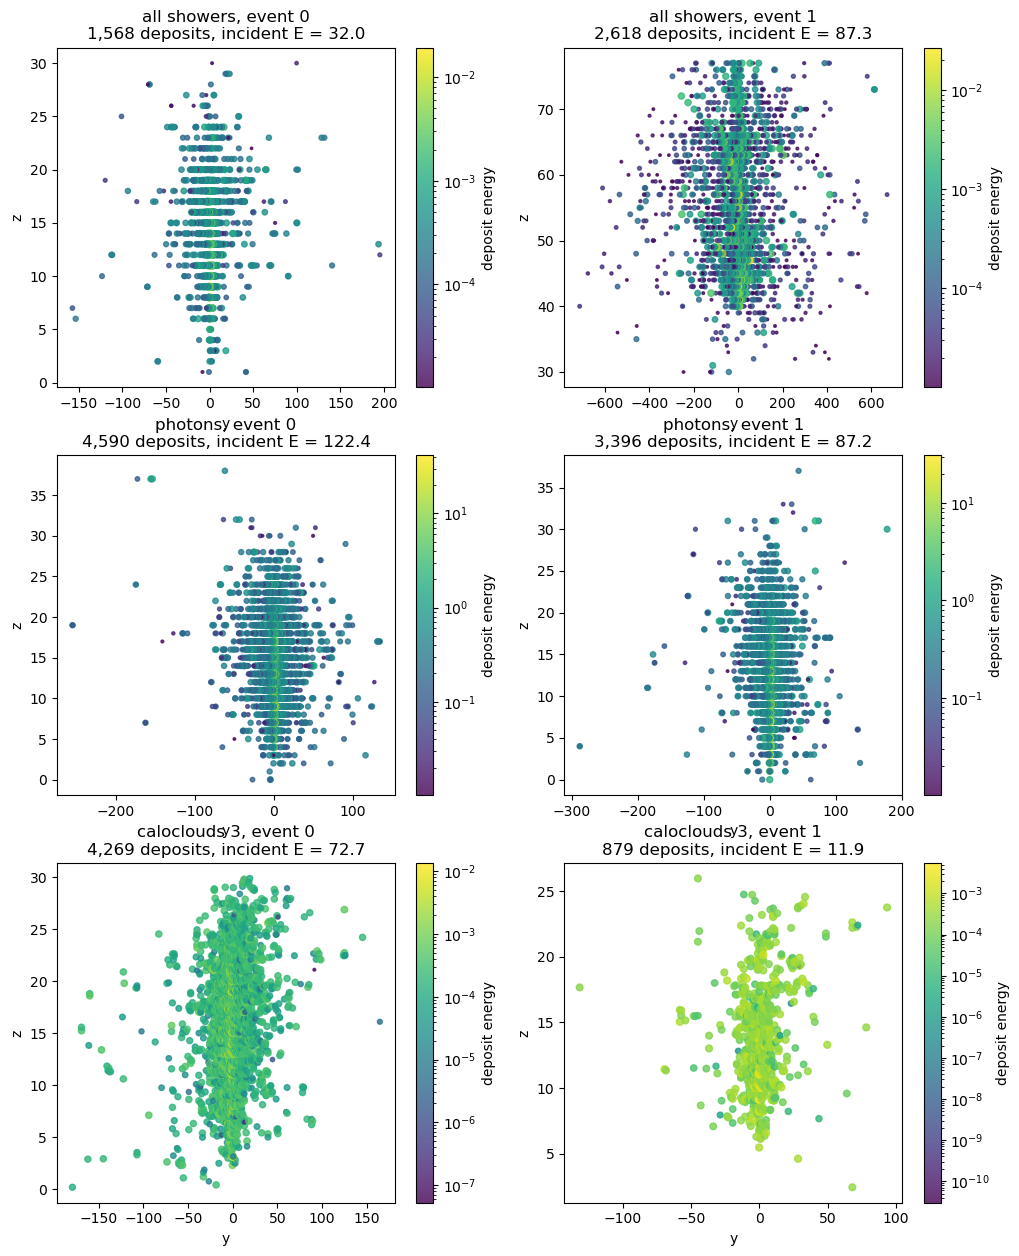

In [21]:

# ---------------------------------------------------------------------------
# 1. two events per dataset, viewed down the x axis (so y across, z up)
# ---------------------------------------------------------------------------
file_lists = {name: dataset_files(config) for name, config in datasets.items()}
for name, files in file_lists.items():
    print(f"{name}: {len(files)} files")
 
fig, axes = plt.subplots(len(datasets), len(EVENT_INDICES),
                         figsize=(6 * len(EVENT_INDICES), 5 * len(datasets)),
                         squeeze=False)
for row, (name, config) in enumerate(datasets.items()):
    for col, (index, event, incident_e) in enumerate(
            read_single_events(config, file_lists[name])):
        ax = axes[row, col]
        energy = event[:, ENERGY_COL]
        # size on a log scale too, or the low energy hits vanish
        log_e = np.log10(energy)
        spread = np.ptp(log_e)
        sizes = 3 + 25 * ((log_e - log_e.min()) / spread if spread > 0
                          else np.ones_like(log_e))
        scatter = ax.scatter(event[:, 1], event[:, 2], c=energy, s=sizes,
                             cmap="viridis", norm=LogNorm(), alpha=0.8)
        fig.colorbar(scatter, ax=ax, label="deposit energy")
        ax.set_xlabel("y")
        ax.set_ylabel("z")
        ax.set_title(f"{name}, event {index}\n"
                     f"{len(event):,} deposits, "
                     f"incident E = {float(incident_e):.1f}")
 


all showers: 2,000,000 events
photons: 168,763 events
caloclouds 3: 3,068,932 events


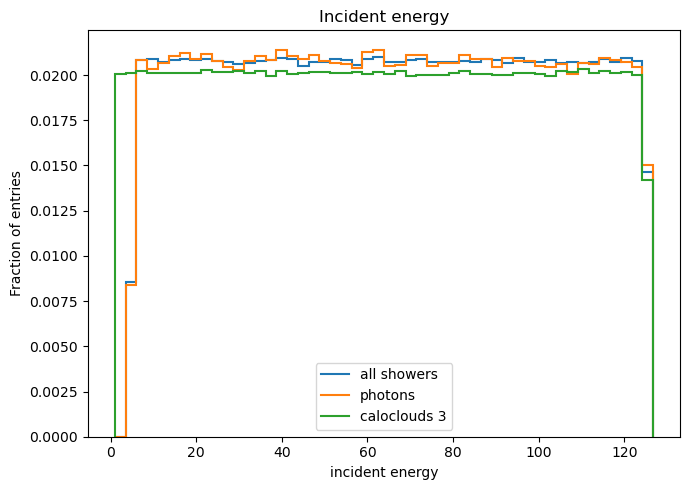

Text(0.5, 0.98, 'Incident direction')

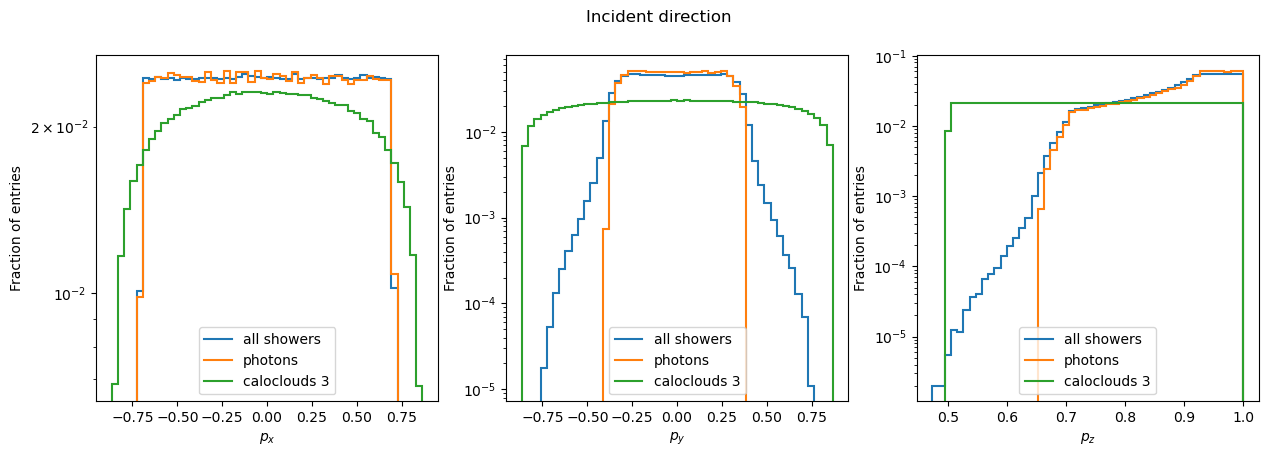

In [22]:
 
# ---------------------------------------------------------------------------
# 2. and 3. incident energy and direction (event level, small enough to load)
# ---------------------------------------------------------------------------
incident_energy, incident_direction = {}, {}
for name, config in datasets.items():
    energies, directions = [], []
    for path in file_lists[name]:
        with h5py.File(path, "r") as open_file:
            energies.append(read_incident_energy(open_file, config))
            directions.append(read_incident_direction(open_file, config))
    incident_energy[name] = np.concatenate(energies)
    incident_direction[name] = np.concatenate(directions, axis=0)
    print(f"{name}: {len(incident_energy[name]):,} events")
 
energy_edges = make_edges(min(e.min() for e in incident_energy.values()),
                          max(e.max() for e in incident_energy.values()))
fig, ax = plt.subplots(figsize=(7, 5))
for name, energies in incident_energy.items():
    plot_counts(ax, energy_edges, np.histogram(energies, bins=energy_edges)[0], name)
ax.set_xlabel("incident energy")
ax.set_title("Incident energy")
ax.legend()
finish(fig, "incident_energy")
 
n_components = min(d.shape[1] for d in incident_direction.values())
fig, axes = plt.subplots(1, n_components, figsize=(5 * n_components, 4.5),
                         squeeze=False)
for component in range(n_components):
    ax = axes[0, component]
    values = [d[:, component] for d in incident_direction.values()]
    edges = make_edges(min(v.min() for v in values), max(v.max() for v in values))
    for name, direction in incident_direction.items():
        counts = np.histogram(direction[:, component], bins=edges)[0]
        plot_counts(ax, edges, counts, name)
    ax.set_xlabel(DIRECTION_LABELS[component])
    ax.set_yscale("log")
    ax.legend()
fig.suptitle("Incident direction")
 


In [ ]:

# ---------------------------------------------------------------------------
# 4. and 5. deposit energy and x, y, z; two streaming passes over the files
# ---------------------------------------------------------------------------
try:
    print(lows.keys())
except Exception:
    lows, highs = {}, {}
    
for name, config in datasets.items():
    if name in lows:
        continue
    print(f"Scanning point ranges for {name}")
    lows[name], highs[name], n_deposits = scan_point_ranges(config, file_lists[name])
    print(f"  {n_deposits:,} deposits; "
          f"ranges {dict(zip(POINT_LABELS, zip(lows[name], highs[name])))}")
 
# shared binning, so the two datasets can go on the same axes
point_edges = [
    make_edges(min(low[col] for low in lows.values()),
               max(high[col] for high in highs.values()),
               log=(LOG_ENERGY_BINS and col == ENERGY_COL))
    for col in range(len(POINT_LABELS))
]

try:
    print(point_counts.keys())
except Exception:
    point_counts = {}

for name, config in datasets.items():
    if name in point_counts:
        continue
    print(f"Filling point histograms for {name}")
    point_counts[name] = fill_point_hists(config, file_lists[name], point_edges)
 
fig, ax = plt.subplots(figsize=(7, 5))
for name, counts in point_counts.items():
    plot_counts(ax, point_edges[ENERGY_COL], counts[ENERGY_COL], name)
if LOG_ENERGY_BINS:
    ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("deposit energy")
ax.set_title("Deposit energy")
ax.legend()
finish(fig, "deposit_energy")
 
position_cols = [col for col in range(len(POINT_LABELS)) if col != ENERGY_COL]
fig, axes = plt.subplots(1, len(position_cols),
                         figsize=(5 * len(position_cols), 4.5), squeeze=False)
for ax, col in zip(axes[0], position_cols):
    for name, counts in point_counts.items():
        plot_counts(ax, point_edges[col], counts[col], name)
    ax.set_xlabel(f"deposit {POINT_LABELS[col]}")
    ax.set_yscale("log")
    ax.legend()
fig.suptitle("Deposit positions")


Scanning point ranges for all showers
  ranges, file 157/200, 3,621,405,428 deposits so far